In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [38]:
dataset = np.genfromtxt('diabetes.csv', delimiter=',', skip_header=1)


In [86]:
X = dataset[:, :-1]
y = dataset[:, -1]
def normalize(X):
    X_minimum = X.min(axis=0)
    X_maximum = X.max(axis=0)
    return (X - X_minimum) / (X_maximum - X_minimum + 1e-8)

X_normalized = normalize(X)


In [87]:

np.random.seed(112320065)

indices = np.arange(len(X_normalized))
np.random.shuffle(indices)

split = int(0.7 * len(indices))

train_indices = indices[:split]
test_indices  = indices[split:]

X_training = X_normalized[train_indices]
y_training = y[train_indices]
X_testing  = X_normalized[test_indices]
y_testing  = y[test_indices]


In [82]:
def euclidean_distance(point1, point2):
    total = 0.0
    for v1, v2 in zip(point1, point2):
        total += (v1 - v2) ** 2
    return math.sqrt(total)



In [90]:
def knn_predict(X_training, y_training, test_point, k):
    distances = []

    for i in range(len(X_training)):
        dist = euclidean_distance(X_training[i], test_point)
        distances.append((dist, y_training[i]))

    distances.sort()

    k_labels = [label for _, label in distances[:k]]

    predicted = max(set(k_labels), key=k_labels.count)

    return predicted

In [91]:
k = 1

correct = 0

for i in range(len(X_testing)):
    prediction = knn_predict(X_training, y_training, X_testing[i], k)

    if prediction == y_testing[i]:
        correct += 1

accuracy = correct / len(X_testing)

print(f"K = {k}")
print(f"Correct Predictions = {correct}")
print(f"Total Test Samples = {len(X_testing)}")
print(f"Accuracy = {accuracy*100:.2f}%")

K = 1
Correct Predictions = 161
Total Test Samples = 231
Accuracy = 69.70%


In [ ]:
k = 3

correct = 0

for i in range(len(X_testing)):
    prediction = knn_predict(X_training, y_training, X_testing[i], k)

    if prediction == y_testing[i]:
        correct += 1

accuracy = correct / len(X_testing)

print(f"K = {k}")
print(f"Correct Predictions = {correct}")
print(f"Total Test Samples = {len(X_testing)}")
print(f"Accuracy = {accuracy*100:.2f}%")

K = 3
Correct Predictions = 171
Total Test Samples = 231
Accuracy = 74.03%


In [ ]:
k = 5

correct = 0

for i in range(len(X_testing)):
    prediction = knn_predict(X_training, y_training, X_testing[i], k)

    if prediction == y_testing[i]:
        correct += 1

accuracy = correct / len(X_testing)

print(f"K = {k}")
print(f"Correct Predictions = {correct}")
print(f"Total Test Samples = {len(X_testing)}")
print(f"Accuracy = {accuracy*100:.2f}%")

K = 5
Correct Predictions = 171
Total Test Samples = 231
Accuracy = 74.03%


In [ ]:
k = 7

correct = 0

for i in range(len(X_testing)):
    prediction = knn_predict(X_training, y_training, X_testing[i], k)

    if prediction == y_testing[i]:
        correct += 1

accuracy = correct / len(X_testing)

print(f"K = {k}")
print(f"Correct Predictions = {correct}")
print(f"Total Test Samples = {len(X_testing)}")
print(f"Accuracy = {accuracy*100:.2f}%")

K = 7
Correct Predictions = 170
Total Test Samples = 231
Accuracy = 73.59%


In [93]:
k_values  = [1, 3, 5, 7]
accuracies = []

print(f"{'K':>4}  {'Correct':>9}  {'Total':>7}  {'Accuracy':>10}")
print("-" * 38)

for k in k_values:
    correct = 0
    for i in range(len(X_testing)):
        prediction = knn_predict(X_training, y_training, X_testing[i], k)
        if prediction == y_testing[i]:
            correct += 1

    acc = correct / len(X_testing)
    accuracies.append(acc)
    print(f"{k:>4}  {correct:>9}  {len(X_testing):>7}  {acc*100:>9.2f}%")

   K    Correct    Total    Accuracy
--------------------------------------
   1        161      231      69.70%
   3        171      231      74.03%
   5        171      231      74.03%
   7        170      231      73.59%


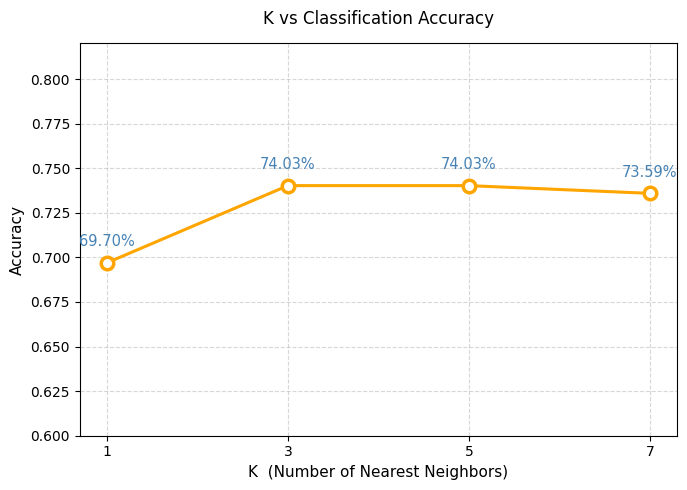

In [92]:
plt.figure(figsize=(7, 5))

plt.plot(k_values, accuracies, marker='o', color='orange',
         linewidth=2.2, markersize=9, markerfacecolor='white',
         markeredgewidth=2.5)


for k, acc in zip(k_values, accuracies):
    plt.annotate(f'{acc*100:.2f}%',
                 xy=(k, acc),
                 xytext=(0, 12),
                 textcoords='offset points',
                 ha='center',
                 fontsize=10.5,
                 color='steelblue')

plt.title('K vs Classification Accuracy', fontsize=12, pad=14)
plt.xlabel('K  (Number of Nearest Neighbors)', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.xticks(k_values)
plt.ylim(0.60, 0.82)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
